energy
(70000, 1)
layer_0
(70000, 3, 96)
layer_1
(70000, 12, 12)
layer_2
(70000, 12, 6)
layer_3
(70000, 3, 96)
layer_4
(70000, 12, 12)
layer_5
(70000, 12, 6)
overflow
(70000, 6)
Minimum Incident Energy (E_inc): 1.0001724157455327
Maximum Incident Energy (E_inc): 99.99933068110775


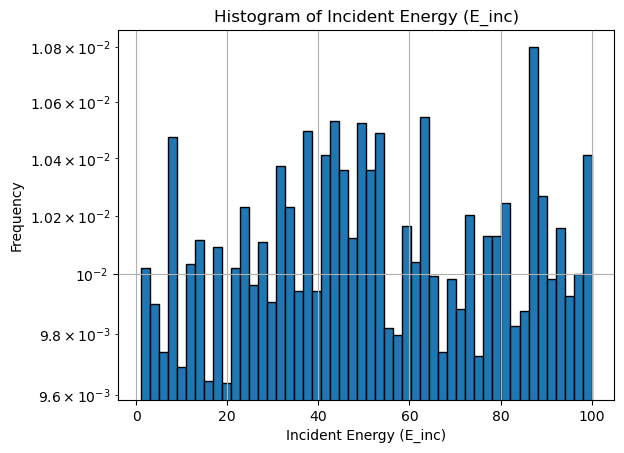

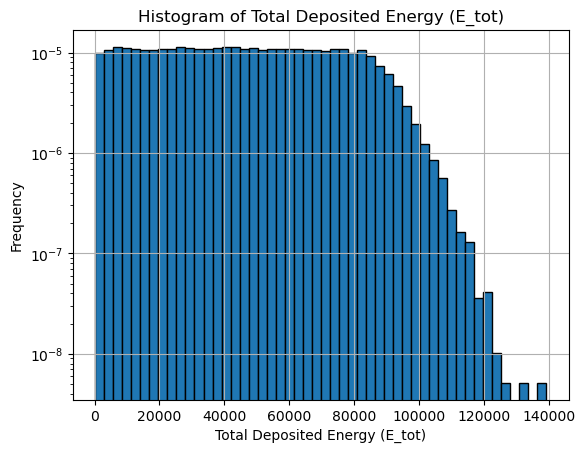

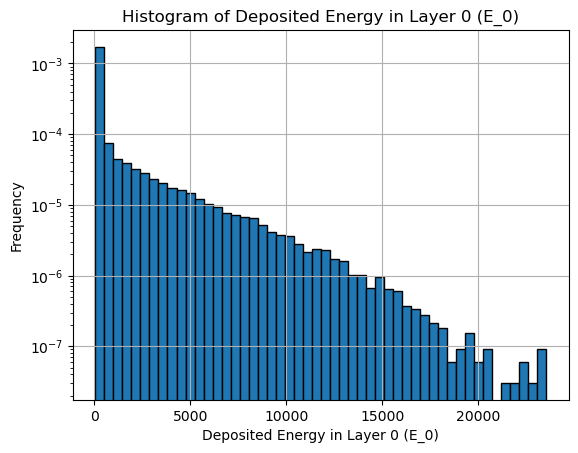

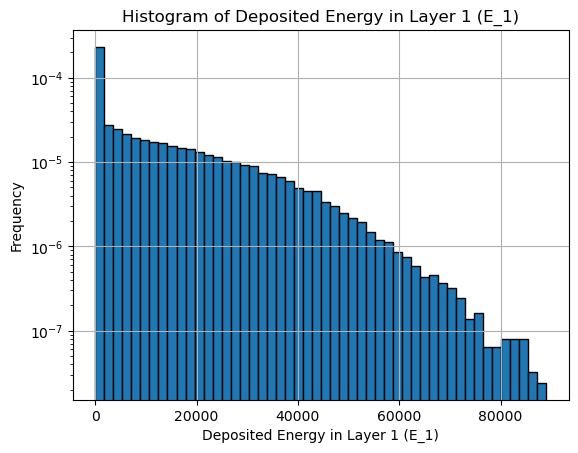

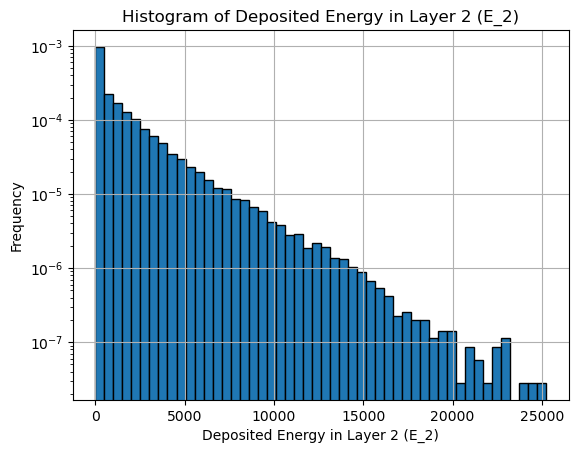

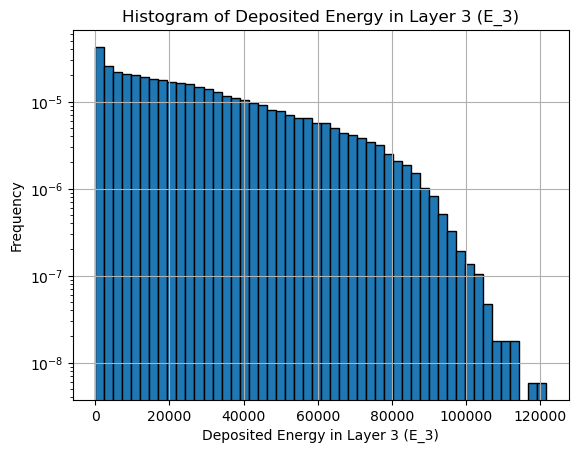

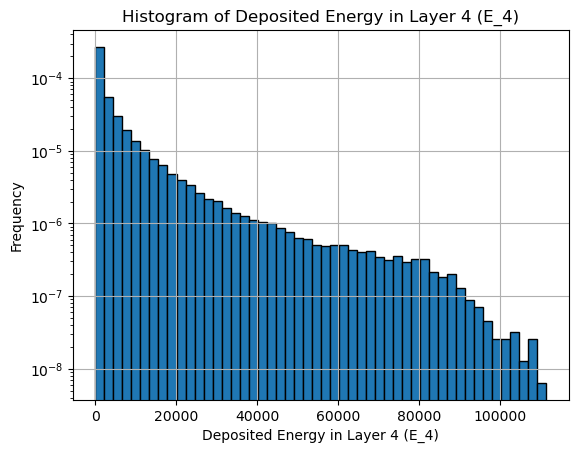

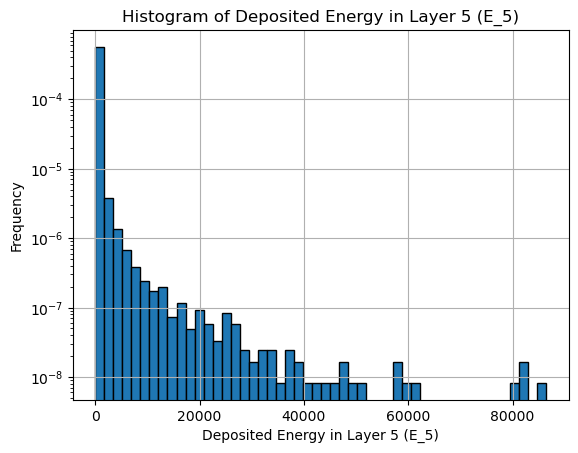

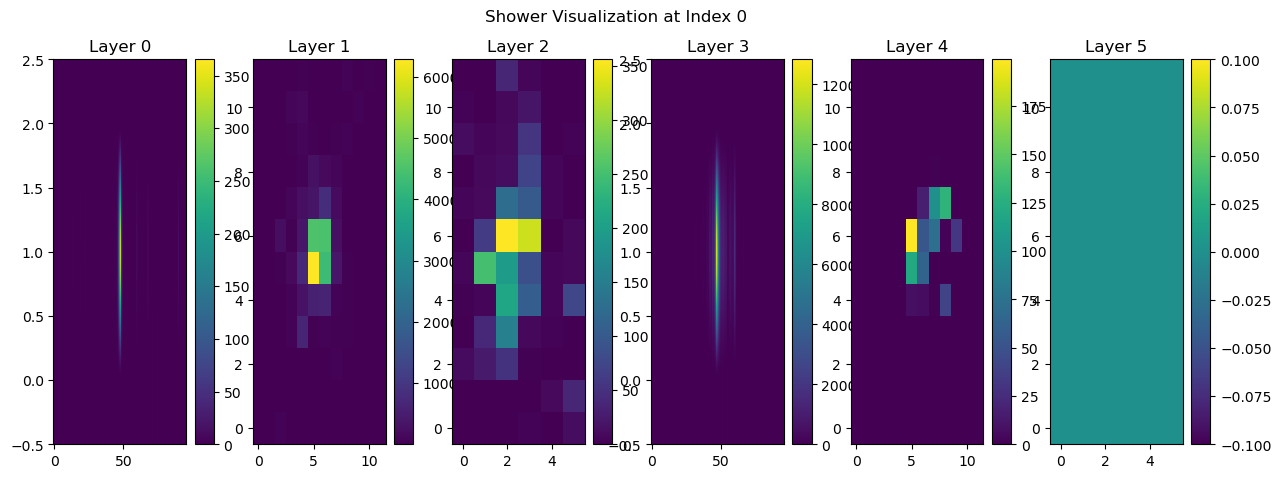

Final samples shape: (100000, 7)
Generated 100000 valid samples.


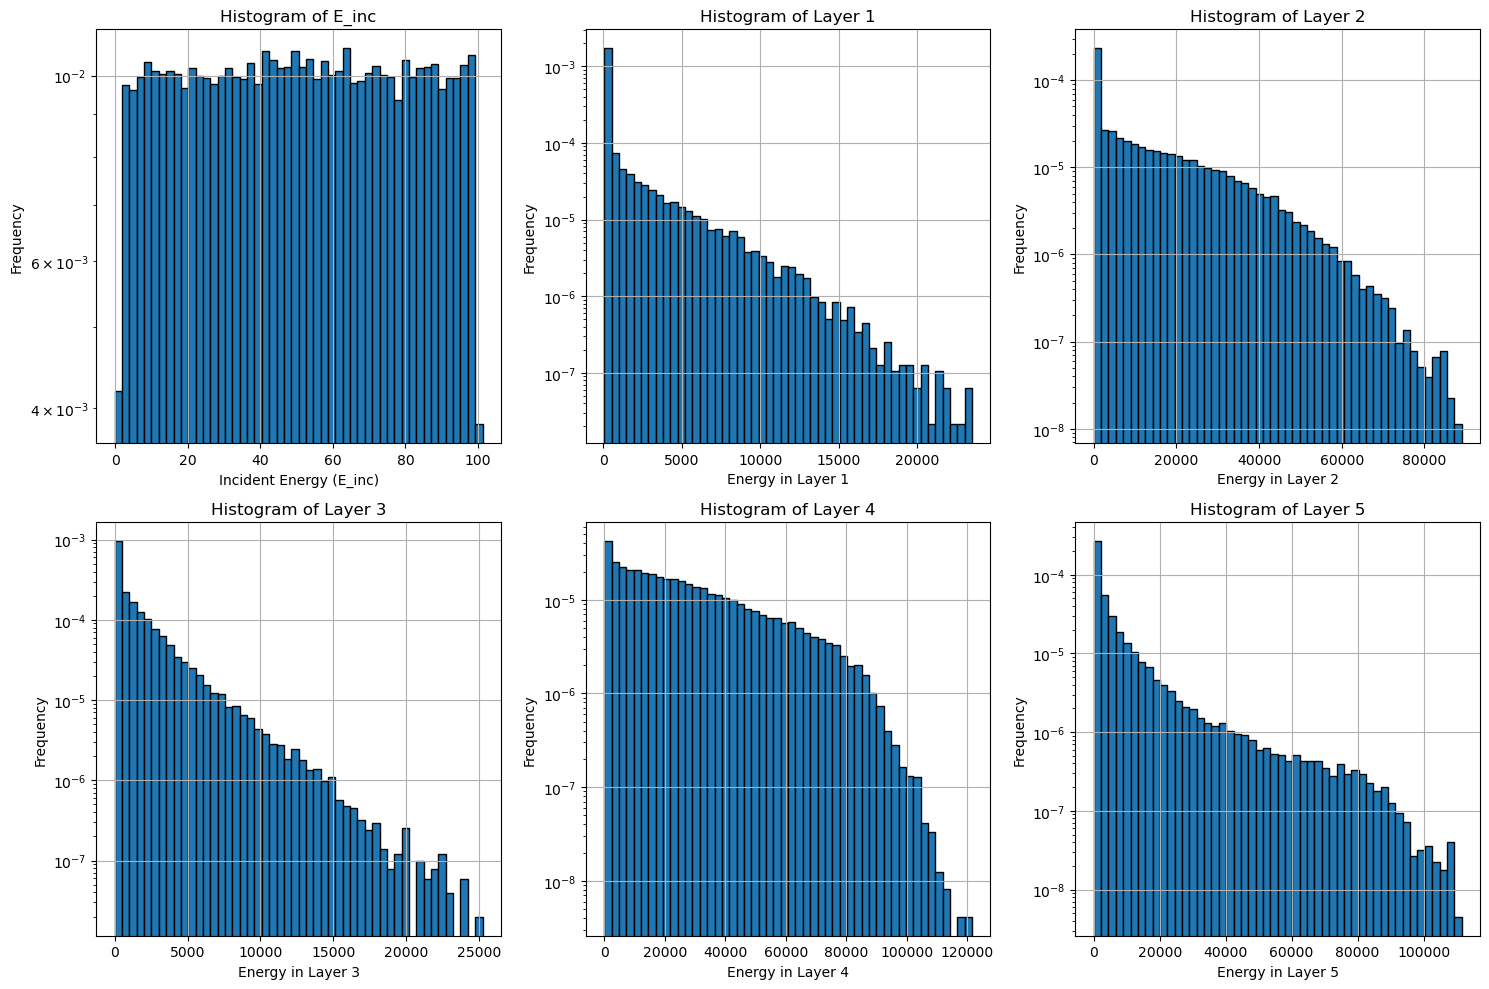

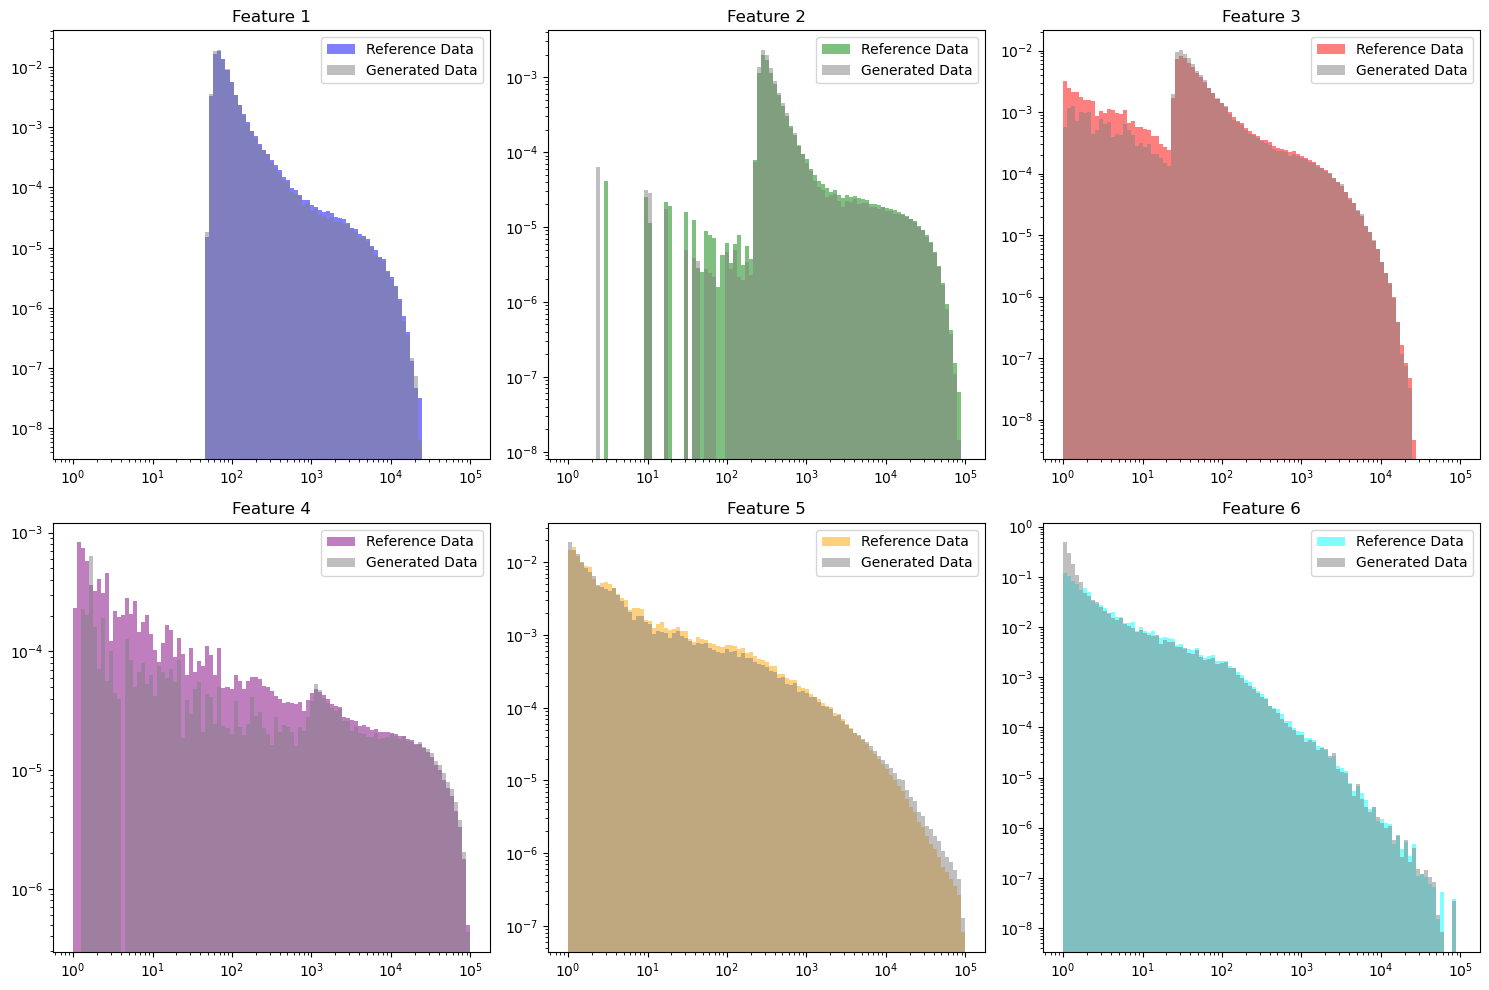

Saved: KDE_results/KDE_layer_energy_histograms_overlay.png
Generative part time (without classifier): 27.90 s
Epoch number 0/24
----------
train Loss: 0.6937 Acc: 0.5020
val Loss: 0.6932 Acc: 0.4995
Epoch number 1/24
----------
train Loss: 0.6933 Acc: 0.4992
val Loss: 0.6932 Acc: 0.4986
Epoch number 2/24
----------
train Loss: 0.6933 Acc: 0.5014
val Loss: 0.6932 Acc: 0.4974
Epoch number 3/24
----------
train Loss: 0.6933 Acc: 0.5004
val Loss: 0.6932 Acc: 0.5002
Epoch number 4/24
----------
train Loss: 0.6933 Acc: 0.5003
val Loss: 0.6933 Acc: 0.4990
Epoch number 5/24
----------
train Loss: 0.6933 Acc: 0.4995
val Loss: 0.6932 Acc: 0.4996
Epoch number 6/24
----------
train Loss: 0.6932 Acc: 0.4986
val Loss: 0.6933 Acc: 0.4992
Epoch number 7/24
----------
train Loss: 0.6932 Acc: 0.5004
val Loss: 0.6932 Acc: 0.5008
Epoch number 8/24
----------
train Loss: 0.6932 Acc: 0.4984
val Loss: 0.6932 Acc: 0.4996
Epoch number 9/24
----------
train Loss: 0.6932 Acc: 0.5007
val Loss: 0.6932 Acc: 0.4982


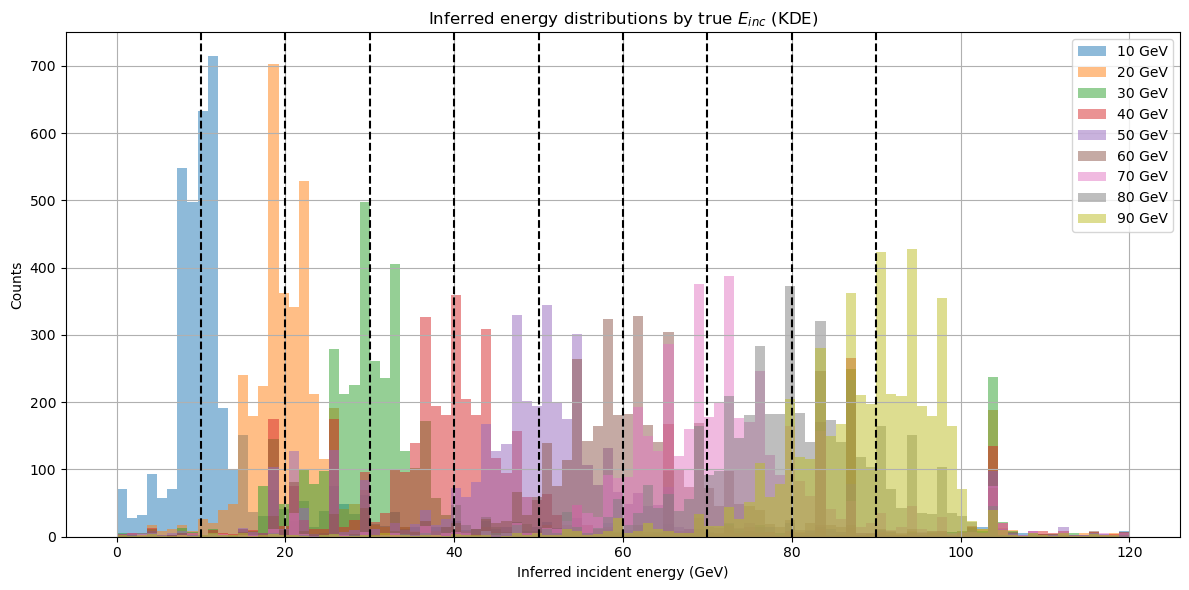

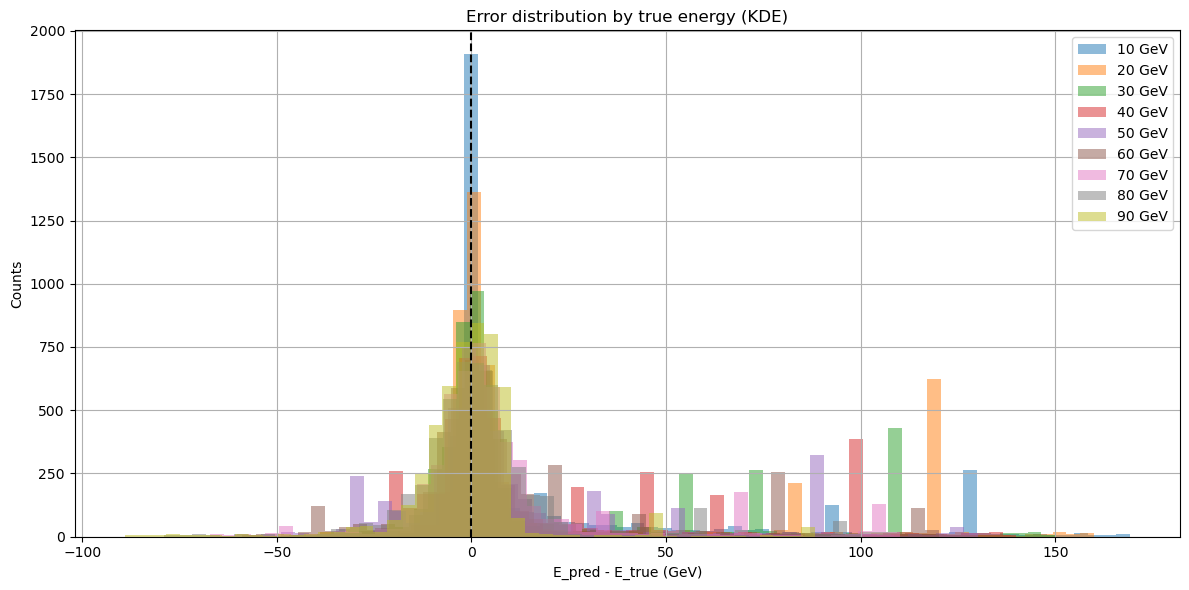


Regression time: 5h 53m 53.85s
Regression part time: 21233.86 s
Total runtime: 21414.84 s
Final classifier accuracy: 0.5008
Final classifier AUC: 0.5008
Best validation accuracy: 0.5008


In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity
import argparse
import os
import torch
import torch.nn.functional as F
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
import torch.nn as nn
import torch.optim as optim
import copy
import time

path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
results_dir = "KDE_results"
os.makedirs(results_dir, exist_ok=True)
SAVE_DPI = 400
results_log = []

def log_print(text=""):
    print(text)
    results_log.append(str(text))

def save_current_figure(filename):
    plt.savefig(os.path.join(results_dir, filename), dpi=SAVE_DPI, bbox_inches="tight")

global_start_time = time.time()
part1_start_time = time.time()

my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')

for key in my_file:
    log_print(key)
    log_print(my_file[key][:].shape)

path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]

min_energy = energy.min()
max_energy = energy.max()
log_print(f"Minimum Incident Energy (E_inc): {min_energy}")
log_print(f"Maximum Incident Energy (E_inc): {max_energy}")

plt.figure()
plt.hist(energy, bins=50, edgecolor='k', density=True, log=True)
plt.xlabel('Incident Energy (E_inc)')
plt.ylabel('Frequency')
plt.title('Histogram of Incident Energy (E_inc)')
plt.grid(True)
save_current_figure("KDE_hist_incident_energy.png")
plt.show()

E_tot = np.sum([layer.sum(axis=(1, 2)) for layer in layers], axis=0)
plt.figure()
plt.hist(E_tot, bins=50, edgecolor='k', density=True, log=True)
plt.xlabel('Total Deposited Energy (E_tot)')
plt.ylabel('Frequency')
plt.title('Histogram of Total Deposited Energy (E_tot)')
plt.grid(True)
save_current_figure("KDE_hist_total_deposited_energy.png")
plt.show()

for i, layer in enumerate(layers):
    E_i = layer.sum(axis=(1, 2))
    plt.figure()
    plt.hist(E_i, bins=50, edgecolor='k', density=True, log=True)
    plt.xlabel(f'Deposited Energy in Layer {i} (E_{i})')
    plt.ylabel('Frequency')
    plt.title(f'Histogram of Deposited Energy in Layer {i} (E_{i})')
    plt.grid(True)
    save_current_figure(f"KDE_hist_layer_{i}_deposited_energy.png")
    plt.show()

shower_index = 0
plt.figure(figsize=(15, 5))
for i, layer in enumerate(layers):
    plt.subplot(1, 6, i+1)
    plt.imshow(layer[shower_index], aspect='auto', origin='lower')
    plt.colorbar()
    plt.title(f'Layer {i}')
plt.suptitle(f'Shower Visualization at Index {shower_index}')
save_current_figure("KDE_shower_visualization.png")
plt.show()

E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T
data = np.hstack((energy.reshape(-1,1), E_layers))

kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(data)

samples = kde.sample(n_samples=100000)

log_print(f"Final samples shape: {samples.shape}")
log_print(f"Generated {len(samples)} valid samples.")

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

for i in range(6):
    axs[i].hist(samples[:, i], bins=50, edgecolor='k',density=True, log=True)
    axs[i].set_xlabel(f'Energy in Layer {i}' if i > 0 else 'Incident Energy (E_inc)')
    axs[i].set_ylabel('Frequency')
    axs[i].set_title(f'Histogram of {"Layer " + str(i) if i > 0 else "E_inc"}')
    axs[i].grid(True)

plt.tight_layout()
save_current_figure("KDE_generated_samples_histograms.png")
plt.show()

samples_plot = samples.copy()
samples_plot = samples_plot[np.all(samples_plot[:, 1:] >= 0, axis=1)]
samples_plot = samples_plot[samples_plot[:, 0] >= 0]

num_features = 6

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()

colors = ['blue', 'green', 'red', 'purple', 'orange', 'cyan']

for i in range(num_features):
    bins = np.logspace(0, 5, 100)

    counts, bin_edges, _ = axs[i].hist(
        data[:, i + 1],
        bins=bins,
        alpha=0.5,
        label="Reference Data",
        color=colors[i % len(colors)],
        density=True,
        log=True
    )

    axs[i].hist(
        samples_plot[:, i + 1],
        bins=bin_edges,
        alpha=0.5,
        label="Generated Data",
        color="grey",
        density=True,
        log=True
    )

    axs[i].set_xscale("log")
    axs[i].legend()
    axs[i].set_title(f"Feature {i + 1}")

plt.tight_layout()
outpath = os.path.join(results_dir, "KDE_layer_energy_histograms_overlay.png")
plt.savefig(outpath, dpi=600, bbox_inches="tight")
plt.show()

log_print(f"Saved: {outpath}")

part1_elapsed = time.time() - part1_start_time
log_print(f"Generative part time (without classifier): {part1_elapsed:.2f} s")

part2_start_time = time.time()

path_to_data = '/groups/hephy/mlearning/CaloRegression/training/'
my_file = h5py.File(path_to_data+'train_piplus.hdf5', 'r')
energy = my_file['energy'][:]
layers = [my_file[f'layer_{i}'][:] for i in range(6)]

E_layers = np.array([layer.sum(axis=(1, 2)) for layer in layers]).T
energy_reshaped = energy.reshape(-1, 1)
data = np.hstack((energy_reshaped, E_layers))

kde = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde.fit(data)

n_samples = len(data)
kde_samples = kde.sample(n_samples)

real_labels = np.ones(n_samples)
kde_labels = np.zeros(n_samples)

combined_data = np.vstack((data, kde_samples))
combined_labels = np.hstack((real_labels, kde_labels))

X_train, X_test, y_train, y_test = train_test_split(
    combined_data, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

class SimpleNN(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

def train_model(model, criterion, optimizer, dataloaders, num_epochs=25):
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    for epoch in range(num_epochs):
        log_print('Epoch number {}/{}'.format(epoch, num_epochs - 1))
        log_print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device).float().unsqueeze(1)
                
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    probs = torch.sigmoid(outputs)
                    preds = torch.round(probs)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)

            log_print('{} Loss: {:.4f} Acc: {:.4f}'.format(
                phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

    log_print('highest validation accuracy: {:4f}'.format(best_acc))
    model.load_state_dict(best_model_wts)
    return model, float(best_acc)

def evaluate_model(model, dataloaders):
    model.eval()
    all_scores = []
    all_preds = []
    all_labels = []

    for inputs, labels in dataloaders['val']:
        inputs = inputs.to(device)
        labels = labels.to(device).float().unsqueeze(1)
        
        with torch.no_grad():
            outputs = model(inputs)
            scores = torch.sigmoid(outputs)
            preds = torch.round(scores)

            all_scores.append(scores.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    all_scores = np.concatenate(all_scores)
    all_preds = np.concatenate(all_preds)
    all_labels = np.concatenate(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_scores)
    log_print('Accuracy: {:.4f}, AUC (area under roc curve): {:.4f}'.format(acc, auc))
    return acc, auc

train_dataset = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32))
test_dataset = torch.utils.data.TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32))

dataloaders = {
    'train': torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True),
    'val': torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)
}

input_dim = combined_data.shape[1]
hidden_dim = 64
model = SimpleNN(input_dim, hidden_dim)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = model.to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model, best_val_acc = train_model(model, criterion, optimizer, dataloaders, num_epochs=25)
final_acc, final_auc = evaluate_model(model, dataloaders)

part2_elapsed = time.time() - part2_start_time
log_print(f"Classifier part time: {part2_elapsed:.2f} s")

part3_start_time = time.time()

kde_E = KernelDensity(kernel='gaussian', bandwidth=0.5)
kde_E.fit(energy.reshape(-1, 1))

eval_folder = '/groups/hephy/mlearning/CaloRegression/evaluation'
energy_values = list(range(10, 91, 10))

NUM_SCAN_POINTS = 200
MAX_EVENTS_PER_FILE = 5000
E_MIN, E_MAX = 1.0, 180.0

reg_start_time = time.time()
errors_by_energy = {}

def load_eval_layers(filepath, max_events=None):
    with h5py.File(filepath, 'r') as f:
        layers_eval = [f[f'layer_{i}'][:] for i in range(6)]
        E_layers_eval = np.array([layer.sum(axis=(1, 2)) for layer in layers_eval]).T
    E_layers_eval = np.clip(E_layers_eval, a_min=0.0, a_max=None)
    if max_events is not None and len(E_layers_eval) > max_events:
        E_layers_eval = E_layers_eval[:max_events]
    return E_layers_eval

def infer_incident_energy_kde_prior_corrected(
    kde_joint,
    kde_energy,
    layer_matrix,
    num_scan_points=NUM_SCAN_POINTS,
    E_min=E_MIN,
    E_max=E_MAX,
    batch_events=250,
    batch_scan=200,
    progress_every=1
):
    n = layer_matrix.shape[0]
    E_candidates = np.linspace(E_min, E_max, num_scan_points).reshape(-1, 1)
    inferred_E = np.empty(n, dtype=np.float64)

    t0 = time.time()
    for start in range(0, n, batch_events):
        end = min(start + batch_events, n)
        X_layers = layer_matrix[start:end]
        B = X_layers.shape[0]

        best_logp = np.full(B, -np.inf, dtype=np.float64)
        best_E = np.full(B, E_candidates[0, 0], dtype=np.float64)

        for s0 in range(0, num_scan_points, batch_scan):
            s1 = min(s0 + batch_scan, num_scan_points)
            E_chunk = E_candidates[s0:s1]
            S = E_chunk.shape[0]

            E_rep = np.repeat(E_chunk, B, axis=0)
            L_rep = np.tile(X_layers, (S, 1))
            flat = np.hstack([E_rep, L_rep])

            logp_joint = kde_joint.score_samples(flat)
            logp_E = kde_energy.score_samples(E_rep)
            logp = logp_joint - logp_E

            logp_SB = logp.reshape(S, B)
            chunk_best = logp_SB.max(axis=0)
            chunk_arg = logp_SB.argmax(axis=0)
            chunk_E = E_chunk[chunk_arg, 0]

            improve = chunk_best > best_logp
            best_logp[improve] = chunk_best[improve]
            best_E[improve] = chunk_E[improve]

        inferred_E[start:end] = best_E

        if progress_every and ((start // batch_events) % progress_every == 0):
            dt = time.time() - t0
            done = end
            rate = done / dt if dt > 0 else 0.0
            eta = (n - done) / rate if rate > 0 else float('inf')
            log_print(f"  progress: {done}/{n} ({100.0*done/n:.1f}%), rate={rate:.1f} ev/s, ETA={eta/60:.1f} min")

    return inferred_E

def _width68(errors):
    errors = np.asarray(errors).reshape(-1)
    return np.quantile(errors, 0.84) - np.quantile(errors, 0.16) if errors.size else np.nan

def _metrics(errors):
    errors = np.asarray(errors).reshape(-1)
    if errors.size == 0:
        return 0, np.nan, np.nan, np.nan, np.nan, np.nan
    bias = float(np.mean(errors))
    mae  = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors**2)))
    std  = float(np.std(errors))
    w68  = float(_width68(errors))
    return int(errors.size), bias, mae, rmse, std, w68

def print_regression_summary(errors_by_energy):
    energies = sorted(errors_by_energy.keys())
    log_print("\n=== Per-energy regression summary (unfiltered) ===")
    log_print(f"{'E_true [GeV]':>10} {'N':>10} {'Bias [GeV]':>11} {'MAE [GeV]':>10} {'RMSE [GeV]':>11} {'Std [GeV]':>10} {'68% width [GeV]':>16} {'Sat. frac':>10}")

    pooled_err = []
    pooled_E = []

    for E in energies:
        err = np.asarray(errors_by_energy[E]).reshape(-1)
        N, bias, mae, rmse, std, w68 = _metrics(err)
        sat_frac = 0.0
        log_print(f"{int(E):10d} {N:10d} {bias:11.3f} {mae:10.3f} {rmse:11.3f} {std:10.3f} {w68:16.3f} {sat_frac:9.2f}%")
        pooled_err.append(err)
        pooled_E.append(np.full(err.size, float(E)))

    pooled_err = np.concatenate(pooled_err) if pooled_err else np.array([])
    pooled_E = np.concatenate(pooled_E) if pooled_E else np.array([])

    N, bias, mae, rmse, std, w68 = _metrics(pooled_err)
    rel_mae  = float(np.mean(np.abs(pooled_err) / pooled_E) * 100.0) if N > 0 else np.nan
    rel_rmse = float(np.sqrt(np.mean((pooled_err / pooled_E) ** 2)) * 100.0) if N > 0 else np.nan

    log_print("\n=== Global regression summary (all energies pooled) ===")
    log_print(f"Total N: {N}")
    log_print(f"Bias  [GeV]: {bias:.3f}")
    log_print(f"MAE   [GeV]: {mae:.3f}")
    log_print(f"RMSE  [GeV]: {rmse:.3f}")
    log_print(f"Std   [GeV]: {std:.3f}")
    log_print(f"68% width [GeV]: {w68:.3f}")
    log_print(f"Relative MAE  [%]: {rel_mae:.3f}")
    log_print(f"Relative RMSE [%]: {rel_rmse:.3f}")

for E_true in energy_values:
    file_path = os.path.join(eval_folder, f'piplus_{E_true}GeV.hdf5')
    layer_mat = load_eval_layers(file_path, max_events=MAX_EVENTS_PER_FILE)

    log_print(f"\n=== E_true={E_true} GeV | events={len(layer_mat)} | scan={NUM_SCAN_POINTS} ===")
    inferred = infer_incident_energy_kde_prior_corrected(kde, kde_E, layer_mat)

    err = inferred - E_true
    errors_by_energy[E_true] = err
    log_print(f"mean error = {np.mean(err):.2f}, std = {np.std(err):.2f}")

print_regression_summary(errors_by_energy)

plt.figure(figsize=(12, 6))
for E_true, err in errors_by_energy.items():
    inferred = err + E_true
    plt.hist(inferred, bins=100, range=(0, 120), alpha=0.5, label=f'{E_true} GeV')
    plt.axvline(E_true, color='black', linestyle='--', label='_nolegend_')

plt.xlabel("Inferred incident energy (GeV)")
plt.ylabel("Counts")
plt.title("Inferred energy distributions by true $E_{inc}$ (KDE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "KDE_inferred_energy_distributions_prior_corrected.pdf"),
            dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 6))
for E_true, err in errors_by_energy.items():
    plt.hist(err, bins=50, alpha=0.5, label=f'{E_true} GeV')

plt.axvline(0, color='black', linestyle='--')
plt.xlabel("E_pred - E_true (GeV)")
plt.ylabel("Counts")
plt.title("Error distribution by true energy (KDE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "KDE_error_distributions_by_energy_prior_corrected.pdf"),
            dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

elapsed = time.time() - reg_start_time
h, rem = divmod(elapsed, 3600)
m, s = divmod(rem, 60)
log_print(f"\nRegression time: {int(h)}h {int(m)}m {s:.2f}s")

part3_elapsed = time.time() - part3_start_time
log_print(f"Regression part time: {part3_elapsed:.2f} s")

total_elapsed = time.time() - global_start_time
log_print(f"Total runtime: {total_elapsed:.2f} s")
log_print(f"Final classifier accuracy: {final_acc:.4f}")
log_print(f"Final classifier AUC: {final_auc:.4f}")
log_print(f"Best validation accuracy: {best_val_acc:.4f}")

with open(os.path.join(results_dir, "KDE_results.txt"), "w") as f:
    for line in results_log:
        f.write(line + "\n")